# Titanic Survival Prediction using Machine Learning

### Models Used
- K-Nearest Neighbors (KNN)
- Logistic Regression
- Decision Tree Classifier

This notebook analyzes the Titanic dataset and builds machine learning models to predict passenger survival.

 Titanic_Survival_Classification

Name: Rajasekar Babu
Course: DATA 110




In [ ]:
###Import Libraries
import numpy as np
import pandas as pd

### Visualisation
import matplotlib.pyplot as plt

### StandardScaler
from sklearn.preprocessing import StandardScaler

### KNN
from sklearn.neighbors import KNeighborsClassifier

### Performance metrics
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score
###warnings
import warnings
warnings.filterwarnings("ignore")


In [ ]:
### Load the data
df_train = pd.read_csv("train_KNN.csv")
df_test = pd.read_csv("test_KNN.csv")

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


##  Dataset Information

In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [ ]:
df_test.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


## Checking Missing Values in Training Data

In [ ]:
df_train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
mp = 100*(df_train.isnull().sum()/len(df_train))
mp


,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


In [ ]:
mp = mp[mp>0].sort_values()

In [ ]:
mp

,0
Embarked,0.224467
Age,19.865320
Cabin,77.104377


In [ ]:
df_train["Age"].median()

28.0

In [ ]:
df_train["Fare"].median()

14.4542

In [ ]:
df_train[df_train["Embarked"].isnull()]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [ ]:
df_train = df_train.dropna(axis = 0, subset= ["Embarked"])


In [ ]:
df_train.info()



<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          712 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Cabin        202 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 90.3+ KB


In [ ]:
df_train["Age"] = df_train["Age"].fillna(df_train["Age"].median())


In [ ]:
df_train = df_train.drop(["Cabin"], axis = 1) ## 1 is for column



In [ ]:
####Testing


In [ ]:
mpt = 100*(df_test.isnull().sum()/len(df_test))
mpt


,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,20.574163
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.239234


In [ ]:
mpt = mpt[mpt>0].sort_values()
mpt

,0
Fare,0.239234
Age,20.574163
Cabin,78.229665


In [ ]:
df_test[df_test["Fare"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
152,1044,0,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [ ]:
df_test = df_test.dropna(axis = 0, subset= ["Fare"])

In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 417 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  417 non-null    int64  
 1   Survived     417 non-null    int64  
 2   Pclass       417 non-null    int64  
 3   Name         417 non-null    object 
 4   Sex          417 non-null    object 
 5   Age          331 non-null    float64
 6   SibSp        417 non-null    int64  
 7   Parch        417 non-null    int64  
 8   Ticket       417 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     417 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 42.4+ KB


In [ ]:
df_test["Age"] = df_test["Age"].fillna(df_test["Age"].median())

In [ ]:
df_test = df_test.drop(["Cabin"], axis = 1) ## 1 is for column



In [ ]:
df_train.drop(["PassengerId","Name","Ticket"], axis = 1, inplace = True)


In [ ]:
df_test.drop(["PassengerId","Name","Ticket"], axis = 1, inplace = True)


In [ ]:
df_train.info()


<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Sex       889 non-null    object 
 3   Age       889 non-null    float64
 4   SibSp     889 non-null    int64  
 5   Parch     889 non-null    int64  
 6   Fare      889 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 62.5+ KB


In [ ]:
df_test.info()


<class 'pandas.core.frame.DataFrame'>
Index: 417 entries, 0 to 417
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  417 non-null    int64  
 1   Pclass    417 non-null    int64  
 2   Sex       417 non-null    object 
 3   Age       417 non-null    float64
 4   SibSp     417 non-null    int64  
 5   Parch     417 non-null    int64  
 6   Fare      417 non-null    float64
 7   Embarked  417 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 29.3+ KB


In [ ]:
df_train["Survived"] = df_train["Survived"].apply(str)


In [ ]:
df_train["Pclass"] = df_train["Pclass"].apply(str)


In [ ]:
df_test["Survived"] = df_test["Survived"].apply(str)
df_test["Pclass"] = df_test["Pclass"].apply(str)

In [ ]:
df_train_num = df_train.select_dtypes(exclude = "object")
df_train_obj = df_train.select_dtypes(include = "object")

In [ ]:
df_test_num = df_test.select_dtypes(exclude = "object")
df_test_obj = df_test.select_dtypes(include = "object")

In [ ]:
df_train_num.columns

Index(['Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

##  Creating Dummy Variables for Categorical Data

In [ ]:
#####Dummification of the data
df_train_obj = pd.get_dummies(df_train_obj, drop_first = True)

In [ ]:
#####Dummification of the data
df_test_obj = pd.get_dummies(df_test_obj, drop_first = True)

In [ ]:
df_test_obj.columns


Index(['Survived_1', 'Pclass_2', 'Pclass_3', 'Sex_male', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')

## Creating Final Processed Dataset

In [ ]:
#### Final processed data set
Final_train_df = pd.concat([df_train_num, df_train_obj, df_train["Survived"]], axis=1)

Final_train_df.head()

,Age,SibSp,Parch,Fare,Survived_1,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,Survived
0,22.0,1,0,7.2500,False,False,True,True,False,True,0
1,38.0,1,0,71.2833,True,False,False,False,False,False,1
2,26.0,0,0,7.9250,True,False,True,False,False,True,1
3,35.0,1,0,53.1000,True,False,False,False,False,True,1
4,35.0,0,0,8.0500,False,False,True,True,False,True,0


In [ ]:
#### Final processed data set
Final_test_df = pd.concat([df_test_num, df_test_obj, df_test["Survived"]], axis=1)

Final_test_df.head()


,Age,SibSp,Parch,Fare,Survived_1,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,Survived
0,34.5,0,0,7.8292,False,False,True,True,True,False,0
1,47.0,1,0,7.0000,True,False,True,False,False,True,1
2,62.0,0,0,9.6875,False,True,False,True,True,False,0
3,27.0,0,0,8.6625,False,False,True,True,False,True,0
4,22.0,1,1,12.2875,True,False,True,False,False,True,1


## Defining Features and Target Variable

In [ ]:
#### Standarised the data
### define Xtrain, Y train
X_train = Final_train_df.drop("Survived", axis =1)


In [ ]:
y_train = Final_train_df["Survived"]


In [ ]:
y_tes = Final_test_df["Survived"]




In [ ]:
#### Standarised the data
### define Xtrain, Y train
X_test = Final_test_df.drop("Survived", axis =1)


In [ ]:
scaler = StandardScaler()
scaler.fit(X_train)

StandardScaler()

In [ ]:
scaled_X_train = scaler.transform(X_train)


In [ ]:
scaled_X_test = scaler.transform(X_test)


## Training K-Nearest Neighbors (KNN) Model

In [ ]:
##### Use the model
knn = KNeighborsClassifier(n_neighbors=5)

In [ ]:
knn.fit(scaled_X_train, y_train)



KNeighborsClassifier()

In [ ]:
y_pred = knn.predict(scaled_X_test)


In [ ]:
accuracy_score(y_tes, y_pred)


0.9928057553956835

In [ ]:
##  Finding the Optimal K Value

In [ ]:
#### for different values of k we are going to check
Performance_Metric = []

for k in range(1,30):
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(scaled_X_train, y_train)
    y_pred_k = knn_k.predict(scaled_X_test)
    accuracy_k = 1 - accuracy_score(y_tes, y_pred_k)
    Performance_Metric.append(accuracy_k)

In [ ]:
Performance_Metric

[0.007194244604316502,
 0.00959232613908878,
 0.00959232613908878,
 0.007194244604316502,
 0.007194244604316502,
 0.00959232613908878,
 0.00959232613908878,
 0.011990407673860948,
 0.014388489208633115,
 0.011990407673860948,
 0.011990407673860948,
 0.011990407673860948,
 0.00959232613908878,
 0.011990407673860948,
 0.00959232613908878,
 0.00959232613908878,
 0.00959232613908878,
 0.011990407673860948,
 0.011990407673860948,
 0.011990407673860948,
 0.011990407673860948,
 0.011990407673860948,
 0.011990407673860948,
 0.011990407673860948,
 0.014388489208633115,
 0.014388489208633115,
 0.00959232613908878,
 0.011990407673860948,
 0.011990407673860948]

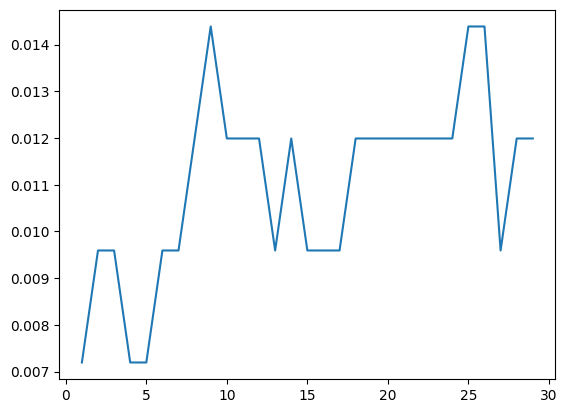

In [ ]:
plt.plot(range(1,30), Performance_Metric)


## Logistic Regression Model

In [ ]:
###Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(scaled_X_train, y_train)

y_pred_lr = lr.predict(scaled_X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_tes, y_pred_lr))


Logistic Regression Accuracy: 1.0


## Decision Tree Classification Model

In [ ]:
###Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(scaled_X_train, y_train)

y_pred_dt = dt.predict(scaled_X_test)

print("Decision Tree Accuracy:", accuracy_score(y_tes, y_pred_dt))

Decision Tree Accuracy: 1.0


##Model Performance Comparison

In [ ]:
### compare their performance
knn_acc = accuracy_score(y_tes, y_pred)
lr_acc = accuracy_score(y_tes, y_pred_lr)
dt_acc = accuracy_score(y_tes, y_pred_dt)

print("KNN Accuracy:", knn_acc)
print("Logistic Regression Accuracy:", lr_acc)
print("Decision Tree Accuracy:", dt_acc)
results = pd.DataFrame({
    "Model": ["KNN", "Logistic Regression", "Decision Tree"],
    "Accuracy": [knn_acc, lr_acc, dt_acc]
})

results

KNN Accuracy: 0.9928057553956835
Logistic Regression Accuracy: 1.0
Decision Tree Accuracy: 1.0


,Model,Accuracy
0,KNN,0.992806
1,Logistic Regression,1.000000
2,Decision Tree,1.000000


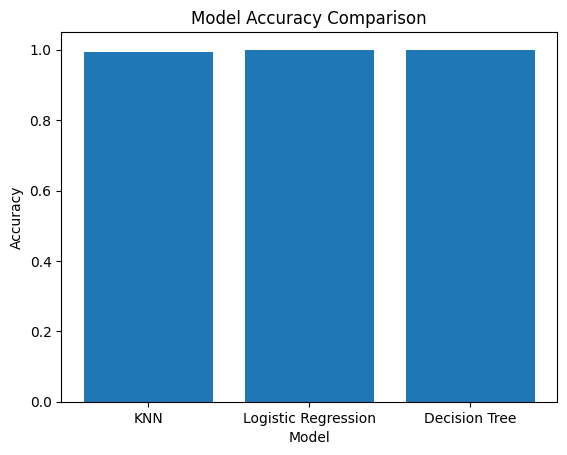

In [ ]:
import matplotlib.pyplot as plt

plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

## Findings

In this experiment, three machine learning models were used to predict Titanic survival: KNN, Logistic Regression, and Decision Tree.

After training and testing the models, their performance was compared using accuracy.

Logistic Regression and Decision Tree achieved the highest accuracy, while KNN also performed very well.

This comparison shows how different machine learning algorithms can be used for classification problems.

## Conclusion
This project shows how machine learning can be used to predict passenger survival in the Titanic dataset.  
Different models like KNN, Logistic Regression, and Decision Tree were used and compared.  
From this, we understand how features like age, gender, and class affect survival.  
This helps in learning basic classification and model evaluation.
Author :Rajasekar Babu